In [7]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from pathlib import Path
project_dir = Path("..").resolve()
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))
from src.dataset import TreeDataset
from src.tree_isolation import treeIso
from src.tree_alignment import align_tree
from src.evaluation import calculate_metrics

# Select tree
treeName = "R01N03"

# Load dataset
data_dir = project_dir / "data/raw/Dataset (With Summer GT)"
dataset = TreeDataset(data_dir)

tree = dataset.get_tree(treeName)

# Default parameters
default_parameters = {
    "depth_threshold": 120,
    "colour_threshold": 18,
    "dilation_iterations": 5,
    "ground_threshold": 0.7
}

# Parameter values to test
parameter_tests = {
    "depth_threshold": [80, 100, 120, 140, 160],
    "colour_threshold": [10, 14, 18, 22, 26],
    "dilation_iterations": [1, 3, 5, 7, 9],
    "ground_threshold": [0.5, 0.6, 0.7, 0.8, 0.9]
}

In [8]:
results = {}

for parameter, values in parameter_tests.items():

    results[parameter] = []

    for value in values:

        # Use default parameters
        parameters = default_parameters.copy()

        # Change only the parameter being tested
        parameters[parameter] = value

        # Isolate tree
        prediction = treeIso(treeName, **parameters)

        try:
            # Align ground truth
            gt_aligned, pred_point, gt_point = align_tree(
                prediction,
                tree.summer_gt,
                scale=0.75
            )

            # Calculate accuracy
            metrics = calculate_metrics(
                prediction,
                gt_aligned
            )

            # Calculate pixel classification
            TP = prediction & gt_aligned
            FP = prediction & ~gt_aligned
            FN = ~prediction & gt_aligned

            # Create colour-coded error image
            height, width = prediction.shape

            error_image = np.zeros(
                (height, width, 3),
                dtype=np.uint8
            )

            error_image[TP] = [0, 255, 0]      # Green
            error_image[FP] = [255, 0, 0]      # Red
            error_image[FN] = [255, 165, 0]    # Orange

        except ValueError:
            # Alignment can fail when no V junction is found
            metrics = {
                "IoU": np.nan,
                "Dice": np.nan,
                "Precision": np.nan,
                "Recall": np.nan
            }

            error_image = None

        # Store results
        results[parameter].append({
            "value": value,
            "metrics": metrics,
            "error_image": error_image
        })

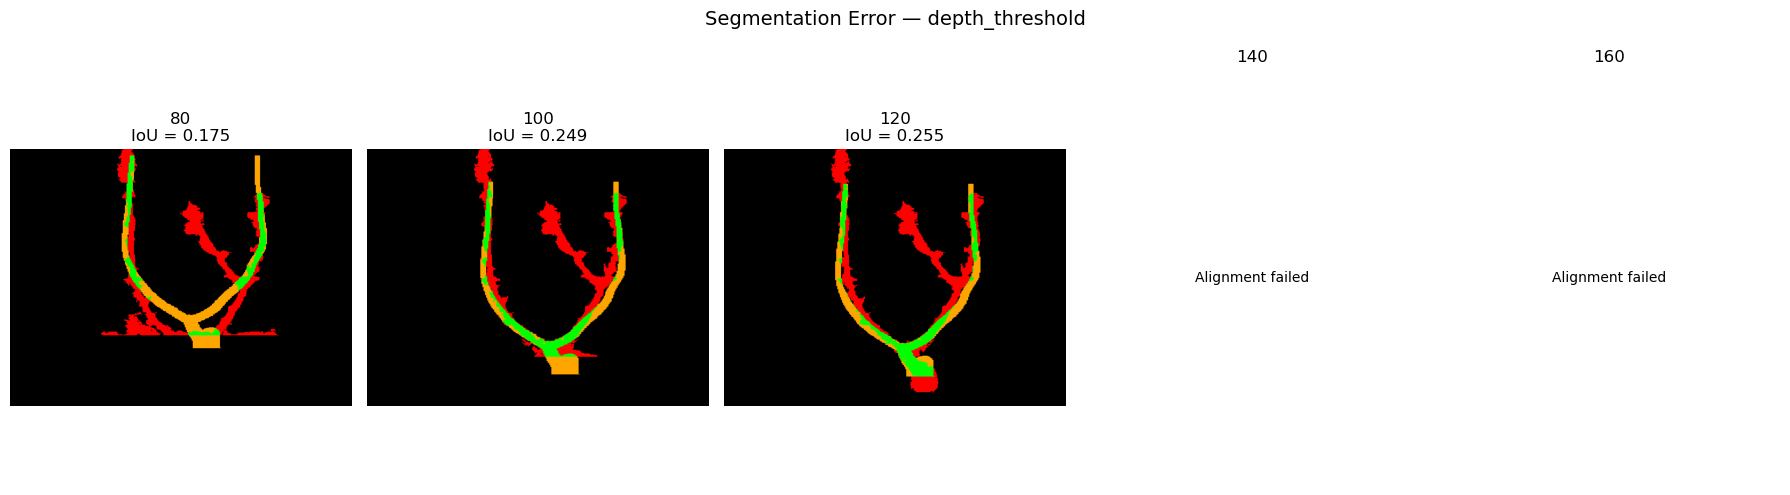

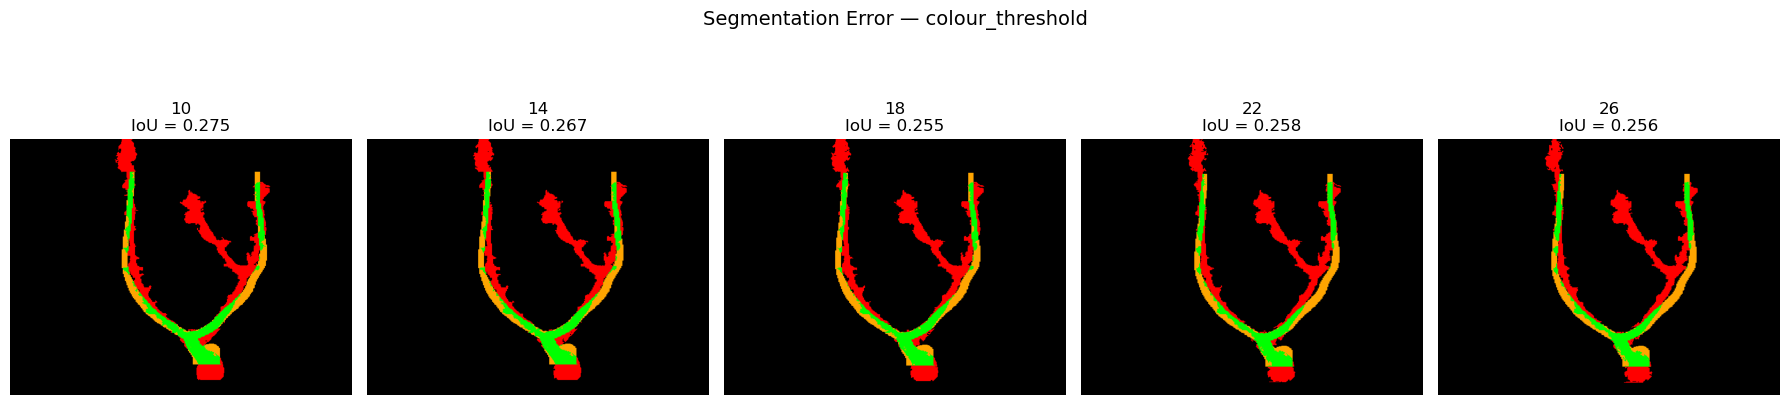

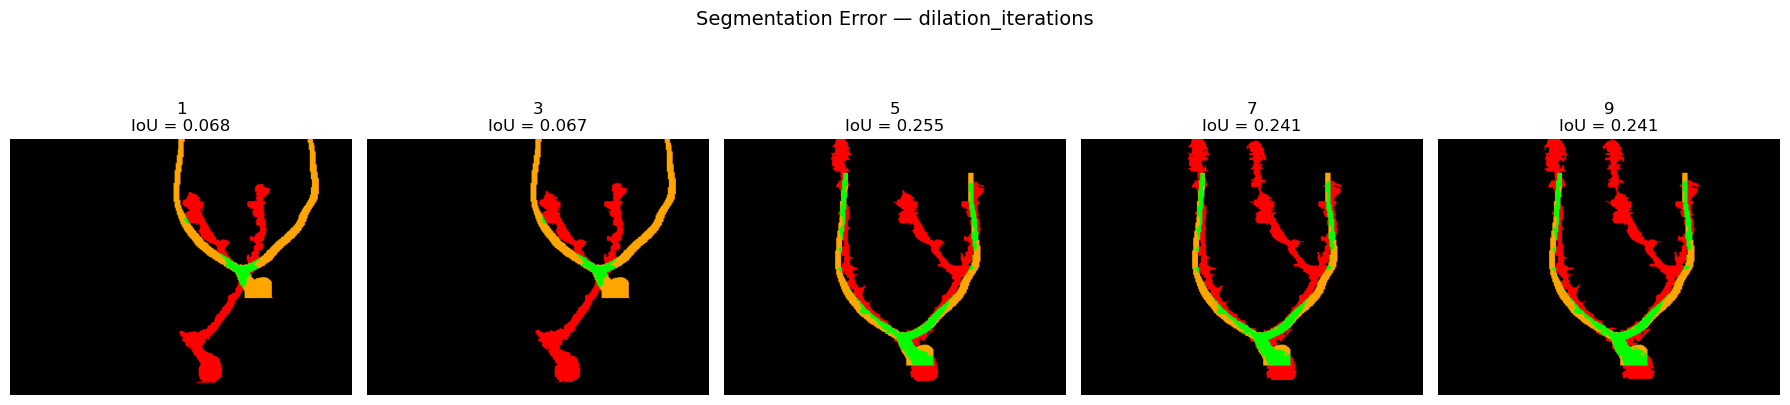

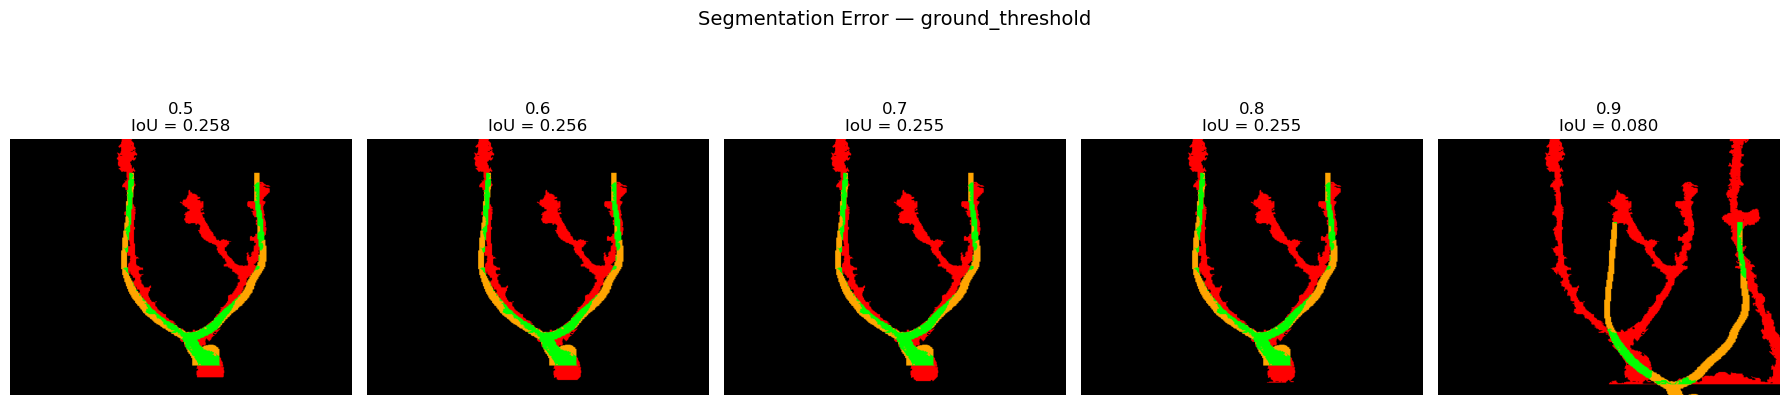

In [9]:
for parameter, tests in results.items():

    fig, axes = plt.subplots(
        1,
        len(tests),
        figsize=(18, 5)
    )

    for ax, test in zip(axes, tests):

        error_image = test["error_image"]
        iou = test["metrics"]["IoU"]

        if error_image is not None:
            ax.imshow(error_image)
            title = f"{test['value']}\nIoU = {iou:.3f}"
        else:
            ax.text(
                0.5, 0.5,
                "Alignment failed",
                ha="center",
                va="center",
                transform=ax.transAxes
            )
            title = str(test["value"])

        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(
        f"Segmentation Error — {parameter}",
        fontsize=14
    )

    plt.tight_layout()
    plt.show()

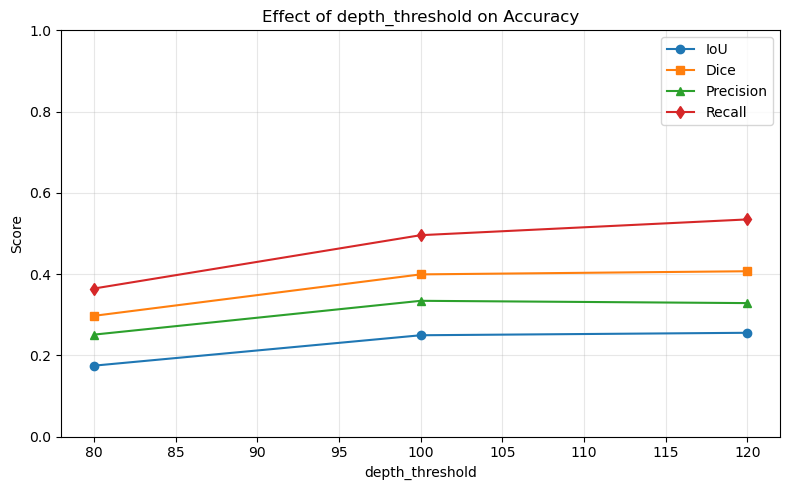

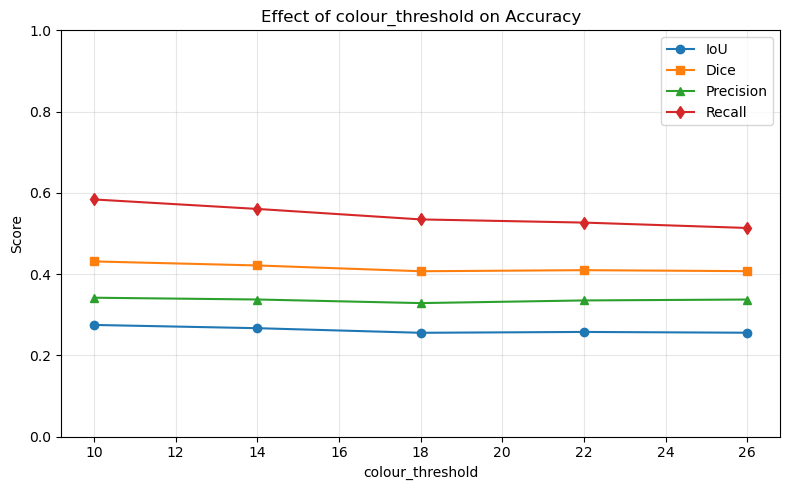

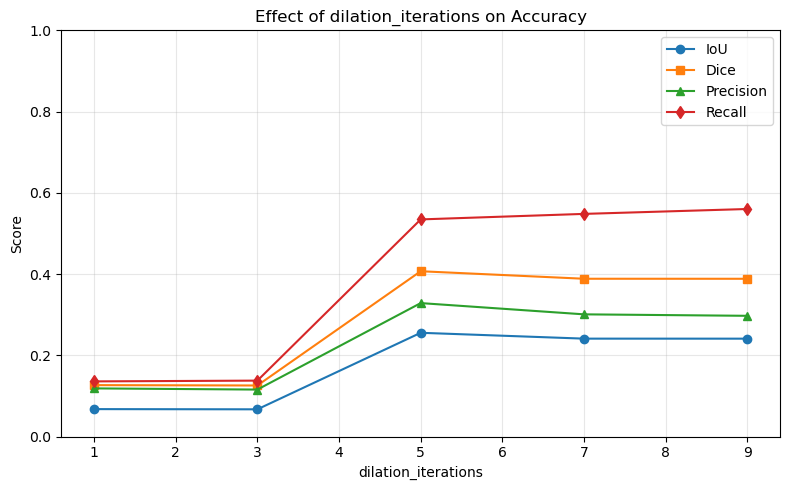

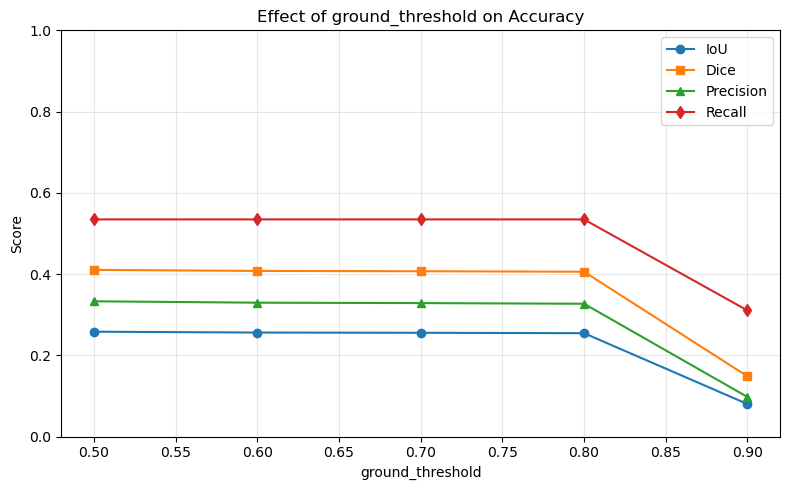

In [10]:
for parameter, tests in results.items():

    values = [test["value"] for test in tests]

    iou = [test["metrics"]["IoU"] for test in tests]
    dice = [test["metrics"]["Dice"] for test in tests]
    precision = [test["metrics"]["Precision"] for test in tests]
    recall = [test["metrics"]["Recall"] for test in tests]

    plt.figure(figsize=(8, 5))

    plt.plot(values, iou, "o-", label="IoU")
    plt.plot(values, dice, "s-", label="Dice")
    plt.plot(values, precision, "^-", label="Precision")
    plt.plot(values, recall, "d-", label="Recall")

    plt.xlabel(parameter)
    plt.ylabel("Score")
    plt.title(f"Effect of {parameter} on Accuracy")

    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [11]:
print("BEST PARAMETER VALUES")
print("-" * 40)

for parameter, tests in results.items():

    valid_tests = [
        test for test in tests
        if np.isfinite(test["metrics"]["IoU"])
    ]

    if not valid_tests:
        print(f"{parameter}: No valid results")
        continue

    best = max(
        valid_tests,
        key=lambda test: test["metrics"]["IoU"]
    )

    print(
        f"{parameter}: {best['value']} "
        f"(IoU = {best['metrics']['IoU']:.4f})"
    )

BEST PARAMETER VALUES
----------------------------------------
depth_threshold: 120 (IoU = 0.2555)
colour_threshold: 10 (IoU = 0.2748)
dilation_iterations: 5 (IoU = 0.2555)
ground_threshold: 0.5 (IoU = 0.2582)


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from src.tree_isolation import treeIso
from src.tree_alignment import align_tree
from src.evaluation import calculate_metrics

# Get all tree IDs from the dataset filenames
tree_ids = sorted(set(
    file.name[:6]
    for file in dataset.data_dir.glob("*.png")
))

print("Number of trees:", len(tree_ids))

# Set to 10 for testing, or None for the full dataset
max_trees = 40

if max_trees is not None:
    tree_ids = tree_ids[:max_trees]

print("Trees being tested:", len(tree_ids))
print("Tree IDs:", tree_ids)

Number of trees: 562
Trees being tested: 40
Tree IDs: ['R01N01', 'R01N02', 'R01N03', 'R01N04', 'R01N05', 'R01N06', 'R01N07', 'R01N08', 'R01N09', 'R01N10', 'R01N11', 'R01N12', 'R01N13', 'R01N14', 'R01N15', 'R01N16', 'R01N17', 'R01N18', 'R01N19', 'R01N20', 'R01N21', 'R01N22', 'R01N23', 'R01N24', 'R01N25', 'R01N26', 'R01N27', 'R01N28', 'R01N29', 'R01N30', 'R01N31', 'R01N32', 'R01N33', 'R01N34', 'R01N35', 'R01N36', 'R01N37', 'R01N38', 'R01N39', 'R01N40']


In [13]:
all_results = []

total_tests = len(tree_ids) * sum(
    len(values) for values in parameter_tests.values()
)

completed = 0

for tree_id in tree_ids:

    # Load ground truth once per tree
    tree = dataset.get_tree(tree_id)

    for parameter, values in parameter_tests.items():

        for value in values:

            # Start with default parameters
            parameters = default_parameters.copy()

            # Change one parameter
            parameters[parameter] = value

            # Set up result
            result = {
                "tree_id": tree_id,
                "parameter": parameter,
                "value": value,
                "IoU": np.nan,
                "Dice": np.nan,
                "Precision": np.nan,
                "Recall": np.nan,
                "status": "failed"
            }

            try:
                # Reconstruct tree
                prediction = treeIso(
                    tree_id,
                    **parameters
                )

                # Align with ground truth
                gt_aligned, pred_point, gt_point = align_tree(
                    prediction,
                    tree.summer_gt,
                    scale=0.75
                )

                # Calculate metrics
                metrics = calculate_metrics(
                    prediction,
                    gt_aligned
                )

                # Store metrics
                result.update(metrics)
                result["status"] = "success"

            except ValueError as e:
                result["status"] = f"alignment_failed: {e}"

            except Exception as e:
                result["status"] = f"error: {e}"

            all_results.append(result)

            completed += 1

    print(
        f"Completed {completed}/{total_tests} tests "
        f"({completed / total_tests * 100:.1f}%)"
    )

# Convert results to DataFrame
df_results = pd.DataFrame(all_results)

display(df_results.head())

Completed 20/800 tests (2.5%)
Completed 40/800 tests (5.0%)
Completed 60/800 tests (7.5%)
Completed 80/800 tests (10.0%)
Completed 100/800 tests (12.5%)
Completed 120/800 tests (15.0%)
Completed 140/800 tests (17.5%)
Completed 160/800 tests (20.0%)
Completed 180/800 tests (22.5%)
Completed 200/800 tests (25.0%)
Completed 220/800 tests (27.5%)
Completed 240/800 tests (30.0%)
Completed 260/800 tests (32.5%)
Completed 280/800 tests (35.0%)
Completed 300/800 tests (37.5%)
Completed 320/800 tests (40.0%)
Completed 340/800 tests (42.5%)
Completed 360/800 tests (45.0%)
Completed 380/800 tests (47.5%)
Completed 400/800 tests (50.0%)
Completed 420/800 tests (52.5%)
Completed 440/800 tests (55.0%)
Completed 460/800 tests (57.5%)
Completed 480/800 tests (60.0%)
Completed 500/800 tests (62.5%)
Completed 520/800 tests (65.0%)
Completed 540/800 tests (67.5%)
Completed 560/800 tests (70.0%)
Completed 580/800 tests (72.5%)
Completed 600/800 tests (75.0%)
Completed 620/800 tests (77.5%)
Completed 640/8

,tree_id,parameter,value,IoU,Dice,Precision,Recall,status
0,R01N01,depth_threshold,80.0,0.174286,0.296838,0.235798,0.400519,success
1,R01N01,depth_threshold,100.0,0.211494,0.349146,0.263903,0.515728,success
2,R01N01,depth_threshold,120.0,0.231984,0.376602,0.296291,0.516640,success
3,R01N01,depth_threshold,140.0,NaN,NaN,NaN,NaN,alignment_failed: Cannot align: V junction not...
4,R01N01,depth_threshold,160.0,NaN,NaN,NaN,NaN,alignment_failed: Cannot align: V junction not...


In [14]:
# Create results folder
results_dir = project_dir / "results"
results_dir.mkdir(parents=True, exist_ok=True)

# Save CSV
output_file = results_dir / "parameter_results.csv"

df_results.to_csv(output_file, index=False)

print("Results saved to:", output_file)

Results saved to: /Users/david/Desktop/Uni/Year 2/Semester2/MMA3001/Project/TreeProject/results/parameter_results.csv


In [15]:
df_results = pd.read_csv(
    project_dir / "results/parameter_results.csv"
)

In [16]:
# Calculate average metrics for each parameter value
summary = (
    df_results
    .groupby(["parameter", "value"])
    .agg(
        mean_IoU=("IoU", "mean"),
        std_IoU=("IoU", "std"),
        mean_Dice=("Dice", "mean"),
        mean_Precision=("Precision", "mean"),
        mean_Recall=("Recall", "mean"),
        successful_tests=("IoU", "count"),
        total_tests=("tree_id", "count")
    )
    .reset_index()
)

summary["success_rate"] = (
    summary["successful_tests"] /
    summary["total_tests"]
)

display(summary)

,parameter,value,mean_IoU,std_IoU,mean_Dice,mean_Precision,mean_Recall,successful_tests,total_tests,success_rate
0,colour_threshold,10.0,0.178534,0.097819,0.291331,0.222709,0.459989,36,40,0.900
1,colour_threshold,14.0,0.177157,0.097982,0.289220,0.223324,0.447023,36,40,0.900
2,colour_threshold,18.0,0.180376,0.095606,0.294387,0.228783,0.449072,34,40,0.850
3,colour_threshold,22.0,0.179649,0.097135,0.292944,0.230688,0.435458,34,40,0.850
4,colour_threshold,26.0,0.175746,0.090518,0.288821,0.226878,0.430962,34,40,0.850
5,depth_threshold,80.0,0.126429,0.072914,0.217334,0.169038,0.336842,35,40,0.875
6,depth_threshold,100.0,0.166560,0.084790,0.276366,0.213724,0.427441,36,40,0.900
7,depth_threshold,120.0,0.180376,0.095606,0.294387,0.228783,0.449072,34,40,0.850
8,depth_threshold,140.0,0.182294,0.080744,0.302114,0.303018,0.338437,4,40,0.100
9,depth_threshold,160.0,NaN,NaN,NaN,NaN,NaN,0,40,0.000


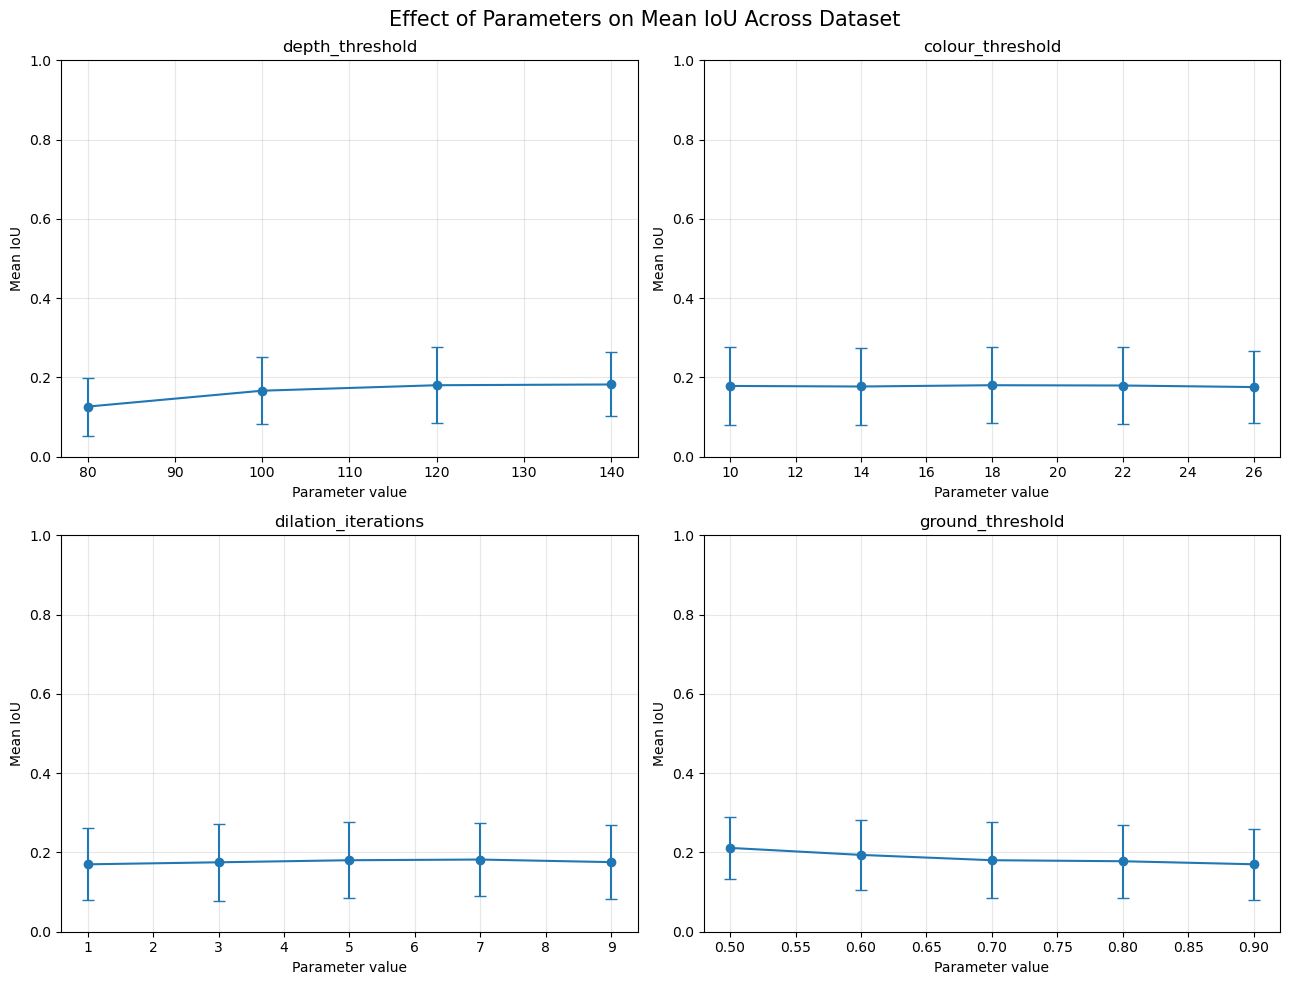

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes = axes.flatten()

for ax, (parameter, values) in zip(
    axes,
    parameter_tests.items()
):

    data = summary[
        summary["parameter"] == parameter
    ].sort_values("value")

    ax.errorbar(
        data["value"],
        data["mean_IoU"],
        yerr=data["std_IoU"].fillna(0),
        fmt="o-",
        capsize=4
    )

    ax.set_title(parameter)
    ax.set_xlabel("Parameter value")
    ax.set_ylabel("Mean IoU")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Effect of Parameters on Mean IoU Across Dataset",
    fontsize=15
)

plt.tight_layout()
plt.show()

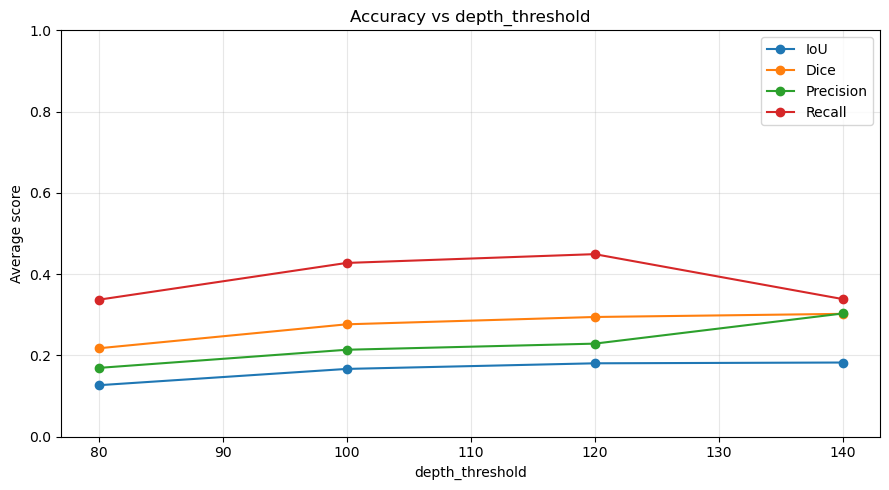

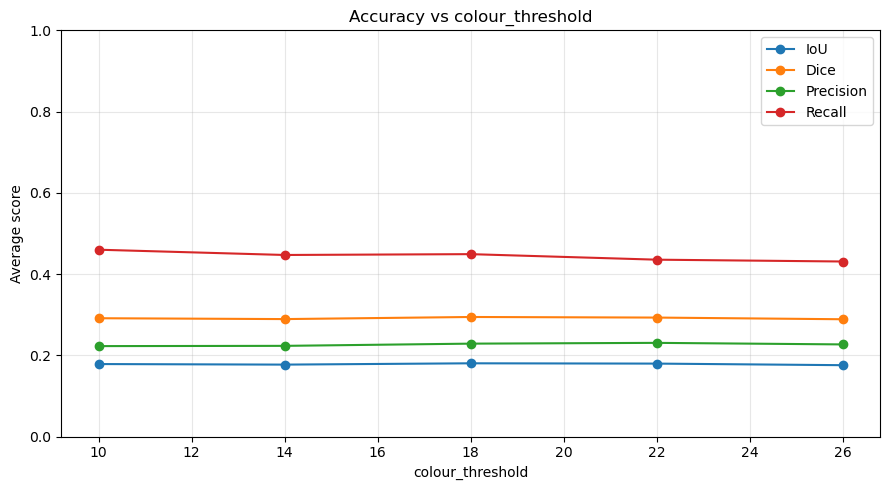

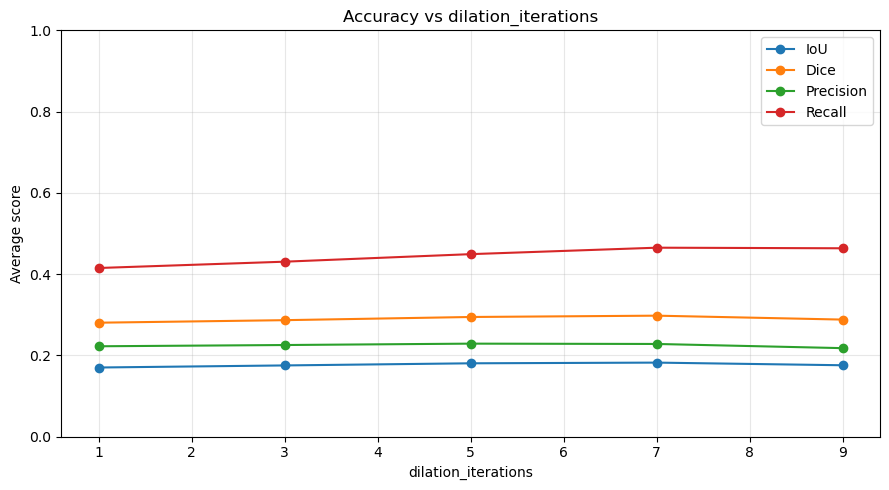

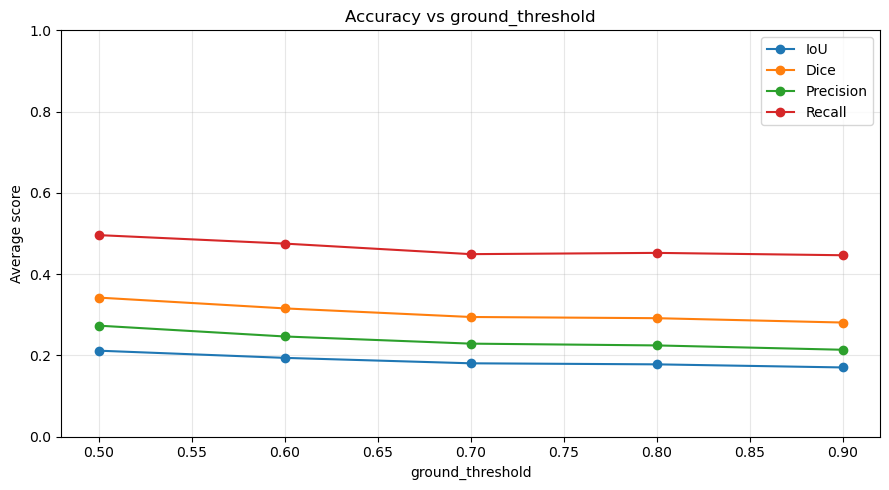

In [18]:
metrics_to_plot = {
    "mean_IoU": "IoU",
    "mean_Dice": "Dice",
    "mean_Precision": "Precision",
    "mean_Recall": "Recall"
}

for parameter in parameter_tests:

    data = summary[
        summary["parameter"] == parameter
    ].sort_values("value")

    plt.figure(figsize=(9, 5))

    for column, label in metrics_to_plot.items():

        plt.plot(
            data["value"],
            data[column],
            marker="o",
            label=label
        )

    plt.title(f"Accuracy vs {parameter}")
    plt.xlabel(parameter)
    plt.ylabel("Average score")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [19]:
print("BEST PARAMETERS ACROSS THE DATASET")
print("-" * 50)

best_parameters = default_parameters.copy()

for parameter in parameter_tests:

    data = summary[
        summary["parameter"] == parameter
    ].dropna(subset=["mean_IoU"])

    if data.empty:
        print(f"{parameter}: No valid results")
        continue

    best = data.loc[data["mean_IoU"].idxmax()]

    best_parameters[parameter] = best["value"]

    print(
        f"{parameter}: {best['value']} "
        f"| Mean IoU = {best['mean_IoU']:.4f} "
        f"| Success rate = {best['success_rate']:.1%}"
    )

print("\nSuggested parameters:")
print(best_parameters)

BEST PARAMETERS ACROSS THE DATASET
--------------------------------------------------
depth_threshold: 140.0 | Mean IoU = 0.1823 | Success rate = 10.0%
colour_threshold: 18.0 | Mean IoU = 0.1804 | Success rate = 85.0%
dilation_iterations: 7.0 | Mean IoU = 0.1821 | Success rate = 90.0%
ground_threshold: 0.5 | Mean IoU = 0.2115 | Success rate = 77.5%

Suggested parameters:
{'depth_threshold': np.float64(140.0), 'colour_threshold': np.float64(18.0), 'dilation_iterations': np.float64(7.0), 'ground_threshold': np.float64(0.5)}


In [20]:
comparison_results = []

parameter_sets = {
    "Default": default_parameters,
    "Suggested": best_parameters
}

for tree_id in tree_ids:

    tree = dataset.get_tree(tree_id)

    for setting_name, parameters in parameter_sets.items():

        result = {
            "tree_id": tree_id,
            "setting": setting_name,
            "IoU": np.nan,
            "Dice": np.nan,
            "status": "failed"
        }

        try:
            prediction = treeIso(
                tree_id,
                **parameters
            )

            gt_aligned, _, _ = align_tree(
                prediction,
                tree.summer_gt,
                scale=0.75
            )

            metrics = calculate_metrics(
                prediction,
                gt_aligned
            )

            result.update(metrics)
            result["status"] = "success"

        except Exception as e:
            result["status"] = str(e)

        comparison_results.append(result)

df_comparison = pd.DataFrame(comparison_results)

display(
    df_comparison.groupby("setting")[
        ["IoU", "Dice"]
    ].mean()
)

,IoU,Dice
setting,,
Default,0.180376,0.294387
Suggested,NaN,NaN
